In [1]:
import matplotlib.pyplot as plt

from neural_astar.planner import VanillaAstar
from neural_astar.utils.data_maps import create_dataloader
from neural_astar.utils.training import load_from_ptl_checkpoint

/home/mastrelli/neural-astar/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from neural_astar.utils.data_maps import visualize_results_voronoi
from neural_astar.utils.data import visualize_results


dataloader = create_dataloader("/home/mastrelli/neural-astar/src/maps_npz", "validation_ds.npz", 1)
map_designs, start_maps, goal_maps, opt_trajs= next(iter(dataloader))

torch.Size([1, 1, 200, 200])


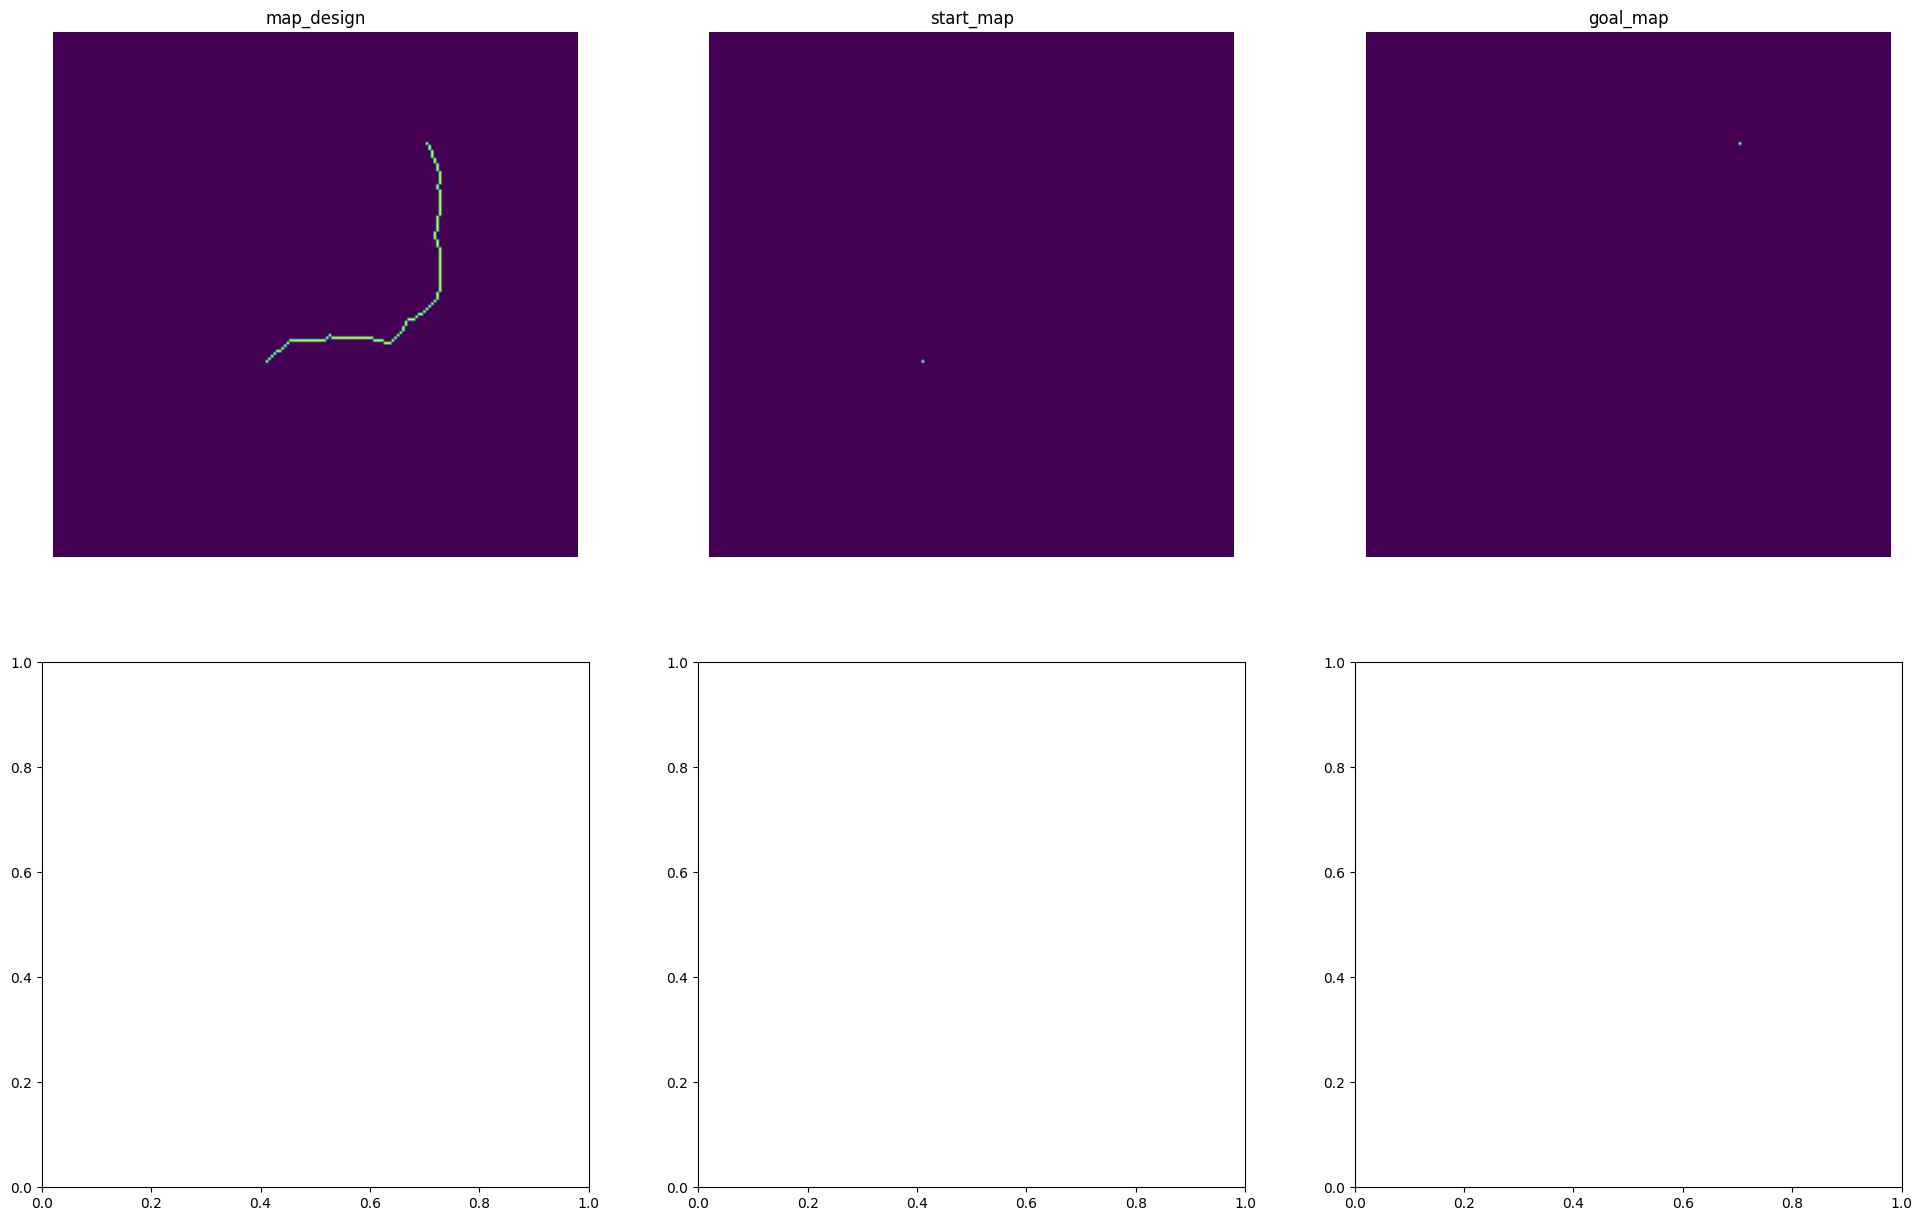

In [3]:
print(start_maps.shape)

fig, axes = plt.subplots(2, 3, figsize=[24, 15])
for i in range(1):
    axes[i, 0].imshow(opt_trajs.numpy()[i, 0])
    axes[i, 0].set_title("map_design")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(start_maps.numpy()[i, 0])
    axes[i, 1].set_title("start_map")
    axes[i, 1].axis("off")
    axes[i, 2].imshow(goal_maps.numpy()[i, 0])
    axes[i, 2].set_title("goal_map")
    axes[i, 2].axis("off")

In [4]:
va = VanillaAstar(use_differentiable_astar=True).to('cuda')
va.eval()
out_g = va(map_designs.to('cuda'), start_maps.to('cuda'), goal_maps.to('cuda'))

/home/mastrelli/neural-astar/.venv/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Text(0.5, 1.0, 'Ground truth')

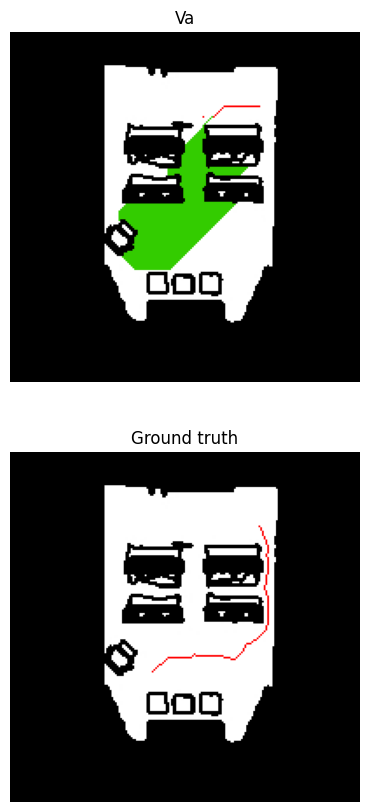

In [6]:
fig, axes = plt.subplots(2, 1, figsize=[30, 10])


axes[0].imshow(visualize_results(map_designs, out_g))
axes[0].set_title("Va")
axes[0].axis("off")
axes[1].imshow(visualize_results_voronoi(map_designs, opt_trajs))
axes[1].axis("off")
axes[1].set_title("Ground truth")